The behaviour where electric wires behave like transmission line does not directly depend on signal's frequency or wire's length. We can determine this using two parameter rise time(Tr) and propagation delay(Td). 

### Rise Time(Tr)
The time signal takes to go from 10% to 90% of its final value. Rise time measures how fast the edges change. Its more crucial value than the signal data rate or frequency as Tr is the one that sets the highest frequency component not the signal's frequency.
### Propagation Delay(Td)  
The time signal takes to reach the end of the line.

If 2·TD is much smaller than Tr, the reflection comes back while the edge is still rising and just blends into i; meaning the sending side signal has the reflected part also. The trace behaves like a lumped wire. 

A trace is considered as transmission line if Td>(Tr/factor). Generally the value of factor is 6(some textbook uses 10).

### Propagation Velocity in FR4

For FR4 materials, we have the dielectric constant:
**eps_eff = 4.3**

Assuming the velocity of light:
**c = 3 * 10^8 m/s**

We know the propagation velocity formula:

$$v = \frac{c}{\sqrt{\text{eps\_eff}}}$$

$$v = \frac{3 \times 10^8}{\sqrt{4.3}}$$

$$v = 1.45 \times 10^8 \text{ m/s}$$

$$v = 5.71 \times 10^{-3} \text{ inch/ps}$$

Thus the delay is:
$$Td =\frac{1}{\text{v}}$$
$$Td =\frac{1}{5.71 \times 10^{-3}}$$
$$Td = 175.13 \text{ ps/inch}$$

### Calculating the critical length

In [3]:
def critical_length(Tr, delay_per_length, factor=6):
     Td=Tr/(factor)
     cric_len=Td/delay_per_length
     return cric_len

print(critical_length(10,175.13,6))

0.009516739945564248


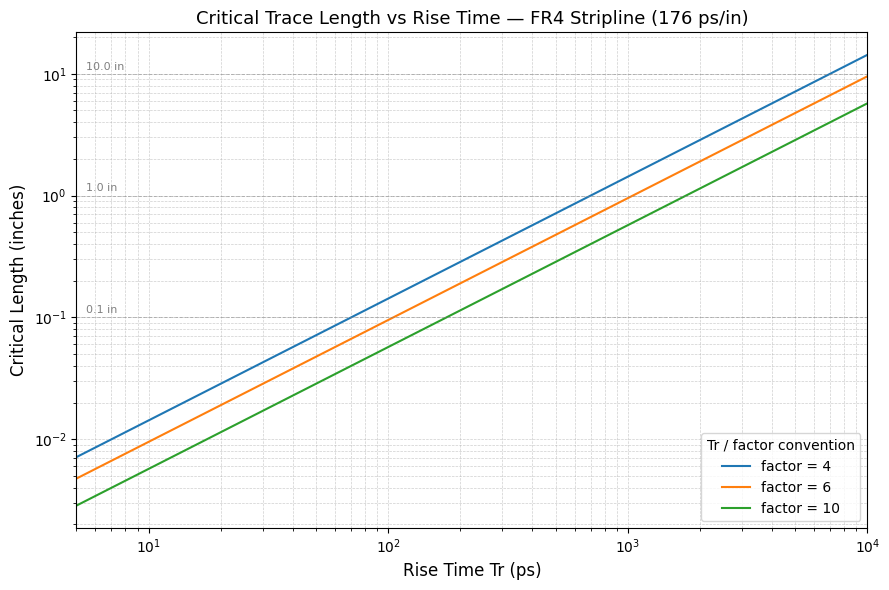

In [4]:
import numpy as np
import matplotlib.pyplot as plt

DELAY_PER_INCH = 175.13 

rise_times = np.logspace(np.log10(5), np.log10(10000), 500)  # ps

fig, ax = plt.subplots(figsize=(9, 6))

for factor in [4, 6, 10]:
    lengths = rise_times / (factor * DELAY_PER_INCH)
    ax.plot(rise_times, lengths, label=f"factor = {factor}")

for length_in in [0.1, 1.0, 10.0]:
    ax.axhline(length_in, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.text(5.5, length_in * 1.08, f"{length_in} in", fontsize=8, color="gray")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rise Time Tr (ps)", fontsize=12)
ax.set_ylabel("Critical Length (inches)", fontsize=12)
ax.set_title("Critical Trace Length vs Rise Time — FR4 Stripline (176 ps/in)", fontsize=13)
ax.legend(title="Tr / factor convention", fontsize=10)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_xlim(5, 10000)

plt.tight_layout()
plt.savefig("critical_length_vs_rise_time.png", dpi=150)
plt.show()

| Signal               | Rise time | Critical length     | Regime            |
|----------------------|-----------|---------------------|-------------------|
| Microcontroller GPIO | ~10 ns    | ≈ 9.5 in (~24 cm)   | Lumped            |
| DDR-class            | ~1 ns     | ≈ 0.95 in (~2.4 cm) | Borderline        |
| PCIe Gen5            | ~12 ps    | ≈ 0.3 mm            | Transmission line |

### for a 100 ps rise time on FR4 stripline (εr ≈ 4.3), what is the critical length, and does a 5 cm trace need transmission-line treatment?

In [9]:
tr=100 #ps
td=175.13 #ps per inch
trace_len=1.96 #inch
crit_len=critical_length(tr,td,6)
print("The critical lenght for this signal:",crit_len, "inch")
if(trace_len>crit_len):
    print("Yes, the trace need a transmission line treatment")
else:
   print("No, It does not")


The critical lenght for this signal: 0.09516739945564248 inch
Yes, the trace need a transmission line treatment
